# **Introdução à orientação ao objeto**

Imagine um programa para um banco financeiro. O programa deve armazenar dados dos clientes e esses devem incluir: titular, número, saldo e limite.

In [509]:
numero = '123-4'
titular = "Pedro"
saldo = 120.0
limite = 1000.0

Se tivermos outros clientes, precisamos repetir o armazenamento:

In [510]:
numero = '345-5'
numero = '111-3'
titular = "Maria"
saldo = 230.0
limite = 1500.0

numero = '234-4'
numero = '556-0'
titular = "Ana"
saldo = 10.0
limite = 500.0

Nosso banco pode ter milhares de contas e, da maneira que está o programa, seria muito trabalhoso dar manutenção.

Podemos ainda armazenar os dados usando dicionários.

In [511]:
conta = {"numero": '123-4', "titular": "Pedro", "saldo": 120.0, "limite": 1000.0}

In [512]:
print(conta['numero'])
print(conta['titular'])

123-4
Pedro


E definir uma função que cria a conta.

In [513]:
def cria_conta(numero, titular, saldo, limite):
  conta = {"numero": numero, "titular": titular, "saldo": saldo, "limite": limite}
  return conta

In [514]:
conta1 = cria_conta('123-4', 'Pedro', 120.0, 1000.0)
conta2 = cria_conta('345-5', 'Maria', 230.0, 1500.0)

Para acessar o número de cada uma delas, fazemos:

In [515]:
print(conta1['numero'])
print(conta2['numero'])

123-4
345-5


Podemos ainda implementar algumas funcionalidades:

In [516]:
def deposita(conta, valor):
  conta['saldo'] = conta['saldo'] + valor

def saca(conta, valor):
  conta['saldo'] -= valor

def extrato(conta):
  print("numero: {} \nsaldo: {}".format(conta['numero'], conta['saldo']))

conta = cria_conta('123-4', 'Pedro', 120.0, 1000.0)
print('Conta criada:')
extrato(conta)

Conta criada:
numero: 123-4 
saldo: 120.0


In [517]:
deposita(conta, 15.0)
extrato(conta)

numero: 123-4 
saldo: 135.0


In [518]:
saca(conta, 20.0)
extrato(conta)

numero: 123-4 
saldo: 115.0


Notem que se tivermos mais funcionalidades, o número de funções que teremos que definir irá crescer. Para resolver isso, integrandos as funções (que chamaremos de métodos) e os valores dos atributos dos clientes, vamos usar orientação ao objeto.

Quando preparamos um bolo, geralmente, seguimos uma receita que define os ingredientes e o
modo de preparação. A nossa conta é um objeto concreto assim como o bolo que também precisa de
uma receita pré-definida. E a "receita" no mundo OO recebe o nome de classe. Ou seja, antes de
criarmos um objeto definiremos uma classe.

Outra analogia que podemos fazer é entre o projeto de uma casa (a planta da casa) e a casa em si. O
projeto é a classe e a casa, construída a partir desta planta, é o objeto. O projeto da conta, isto é, a
definição da conta, é a classe. O que podemos construir (instanciar) a partir dessa classe, as contas de
verdade, damos o nome de objetos.

Vamos criar nossa classe Conta. Vamos
começar criando uma classe vazia. Depois criaremos uma instância, um objeto dessa classe, e
utilizaremos a função type() para analisar o resultado:

In [519]:
class Conta:
  pass

conta = Conta()
type(conta)

__main__.Conta

Dentro da classe, podemos criar os atributos e métodos:
> atributos → que representam o estado do objeto

> métodos → que representam o comportamento do objeto (são funções definidas dentro da classe.)

Dentro da classe, podemos ter um construtor de classe, que é um método especial que é executado automaticamente quando criamos um objeto de uma classe.

Ele serve para inicializar o objeto, isto é:

> definir atributos iniciais

> preparar o estado interno

> garantir que o objeto já nasça consistente

In [520]:
class Conta:
  def __init__(self, numero, titular, saldo, limite):
    self.numero = numero
    self.titular = titular
    self.saldo = saldo
    self.limite = limite

Quando uma classe é criada, todos os seus atributos serão inicializados pelo método \__init\__(). Ou seja, o método \__init\__()é responsável por inicializar o objeto, tanto é que já recebe
a própria instância (self) criada pelo construtor como argumento. E dessa maneira garantimos que toda
instância de uma Conta tenha os atributos que definimos.

Para criar um objeto, usamos:

In [521]:
conta = Conta('123-4', 'Pedro', 120.0, 1000.0)

print(conta.titular)
print(conta.saldo)

Pedro
120.0


Além dos atributos, nossa conta deve possuir funcionalidades. No paradigma orientado a objetos as funcionalidades de um objeto são chamados de métodos - do ponto de vista do código, são as funções dentro de uma classe.

In [522]:
class Conta:
  def __init__(self, numero, titular, saldo, limite):
    self.numero = numero
    self.titular = titular
    self.saldo = saldo
    self.limite = limite

  def saca(self, valor):
    self.saldo = self.saldo - valor

  def deposita(self, valor):
    self.saldo = self.saldo + valor

  def extrato(self):
    print('Número:',self.numero)
    print('Titular:', self.titular)
    print('Saldo:', self.saldo)
    print('Limite:', self.limite)
############### Fim da classe ###############

conta = Conta('123-4', 'Pedro', 120.0, 1000.0)
conta.extrato()

Número: 123-4
Titular: Pedro
Saldo: 120.0
Limite: 1000.0


In [523]:
conta = Conta('123-4', 'Carlos', 120.0, 2000.0)
conta.deposita(20.0)
conta.extrato()

Número: 123-4
Titular: Carlos
Saldo: 140.0
Limite: 2000.0


In [524]:
conta.saca(15)
conta.extrato()

Número: 123-4
Titular: Carlos
Saldo: 125.0
Limite: 2000.0


Vamos adicionar o método transfere.

In [525]:
class Conta:
  def __init__(self, numero, titular, saldo, limite):
    self.numero = numero
    self.titular = titular
    self.saldo = saldo
    self.limite = limite

  def saca(self, valor):
    self.saldo = self.saldo - valor

  def deposita(self, valor):
    self.saldo = self.saldo + valor

  def extrato(self):
    print('Número:',self.numero)
    print('Titular:', self.titular)
    print('Saldo:', self.saldo)

  def transfere(self, destino, valor):
    retirou = self.saca(valor)
    if (retirou == False):
      return False
    else:
      destino.deposita(valor)
      return True
  ############### Fim da classe ###############


conta1 = Conta('123-4', 'Pedro', 120.0, 1000.0)
conta2 = Conta('323-4', 'Maria', 400.0, 2000.0)

Conta.transfere(conta1,conta2,100)
print("Tranfere 100 reais da conta 1 para a conta 2.")
print('Origem******')
conta1.extrato()
print('Destino******')
conta2.extrato()

Tranfere 100 reais da conta 1 para a conta 2.
Origem******
Número: 123-4
Titular: Pedro
Saldo: 20.0
Destino******
Número: 323-4
Titular: Maria
Saldo: 500.0


**Exercício:** Implemente um método que transfere_para(), que seria algo assim:
> conta1.transfere_para(conta2, 50.0)<br>

ou seja, a conta1 transfere para conta2 50 reais

Podemos ainda ter atributos que possuem um valor padrão, por exemplo, limite de 1000.0 reais. Veja abaixo que agora não somos obrigados a passar o valor do de 1000.0

In [526]:
class Conta:
  def __init__(self, numero, titular, saldo, limite=1000.0):
    self.numero = numero
    self.titular = titular
    self.saldo = saldo
    self.limite = limite

  def saca(self, valor):
    self.saldo = self.saldo - valor
  def deposita(self, valor):
    self.saldo = self.saldo + valor
  def extrato(self):
    print('Número:',self.numero)
    print('Titular:', self.titular)
    print('Saldo:', self.saldo)
    print('Limite:', self.limite)
  def transfere(self, destino, valor):
    retirou = self.saca(valor)
    if (retirou == False):
      return False
    else:
      destino.deposita(valor)
      return True

conta1 = Conta('123-4', 'Pedro', 120.0)
conta2 = Conta('323-4', 'Maria', 400.0, 2000.0)

print("********")
conta1.extrato()
print("********")
conta2.extrato()

********
Número: 123-4
Titular: Pedro
Saldo: 120.0
Limite: 1000.0
********
Número: 323-4
Titular: Maria
Saldo: 400.0
Limite: 2000.0


Notem que temos atributos que são do cliente (nome) e da conta (saldo). Então podemos criar uma nova classe e fazer uma agregação - agregar um cliente a nossa conta. Portanto, nossa classe Conta tem um Cliente .

In [527]:
class Cliente:
  def __init__(self, nome, sobrenome, cpf):
    self.nome = nome
    self.sobrenome = sobrenome
    self.cpf = cpf

class Conta:
  def __init__(self, numero, cliente, saldo, limite=1000.0):
    self.numero = numero
    self.titular = cliente
    self.saldo = saldo
    self.limite = limite

  def saca(self, valor):
    self.saldo = self.saldo - valor
  def deposita(self, valor):
    self.saldo = self.saldo + valor
  def extrato(self):
    print('Número:',self.numero)
    print('Titular:', self.titular.nome)
    print('Saldo:', self.saldo)
    print('Limite:', self.limite)
  def transfere(self, destino, valor):
    retirou = self.saca(valor)
    if (retirou == False):
      return False
    else:
      destino.deposita(valor)
      return True

cliente = Cliente('Pedro', 'Oliveira', '1111111111-1')
nova_conta = Conta('123-4', cliente, 120.0, 2000.0)
nova_conta.extrato()

Número: 123-4
Titular: Pedro
Saldo: 120.0
Limite: 2000.0


## Exercício para entregar

1 - Implemente uma classe que permita selecionar o conjunto de treinamento e teste.

In [528]:
import random
import numpy as np

In [529]:
class Separador:

  def __init__(self, data_x, data_y, percent):
    self.x =  data_x
    self.y = data_y
    self.percent = percent
    self.tam = len(self.y)

  def shuffle_set(self):

    # Define ordem aleatoria
    order = []
    for i in range(self.tam):
      order.append(i)
    random.shuffle(order)

    # Ramdomiza vetor
    novo_vector = []
    for i in range(self.tam):
      novo_vector.append(self.y[order[i]])

    # Ramdomiza matriz do mesmo jeito
    nova_matrix = np.zeros(self.x.shape)
    for i in range(self.tam):
      nova_matrix[i] = (self.x[order[i]])

    self.y = novo_vector
    self.x = nova_matrix

  def selecionar(self):
    '''
    Definimos que treinamento sera 70% do tam das amostra e a verificação será 30%
    Assumimos que as informações prioritarias se encontrao nas colunas, então a divisao se dá pelas linhas
    '''
    n_linhas_x, n_colunas_x = self.x.shape #uma matrix
    n_colunas_y = len(self.y) #um vetor
    print(n_colunas_y)
    #verificação do conjunto x
   
    #separando os elementos da matriz
    tam_train_x = int(self.percent * n_linhas_x)
    t_x = self.x[:tam_train_x, :]
    v_x = self.x[tam_train_x:,:]

    #verifica do conjunto y
    tam_train_y = int(self.percent * n_colunas_y)
    t_y = (np.array(self.y[:tam_train_y])).flatten()
    v_y = (np.array(self.y[tam_train_y:])).flatten()


    return t_x, v_x, t_y, v_y



In [530]:
def create_matrix(n_rows, m_cols):
    matrix = np.zeros((n_rows, m_cols)) # Initialize with correct dimensions
    for i in range(n_rows):
        matrix[i,:] = i # Set all elements in row i to i
    return matrix


# Exemplo de uso da função:
n_rows = 10 # Número de linhas
m_cols = 4 # Número de colunas

print('Matriz X:')
X = create_matrix(n_rows, m_cols)
# Exibindo a matriz
for row in X:
    print(row)

print('Vetor y:')
y = create_matrix(n_rows, 1)
# Exibindo a matriz
for row in y:
    print(row)

Matriz X:
[0. 0. 0. 0.]
[1. 1. 1. 1.]
[2. 2. 2. 2.]
[3. 3. 3. 3.]
[4. 4. 4. 4.]
[5. 5. 5. 5.]
[6. 6. 6. 6.]
[7. 7. 7. 7.]
[8. 8. 8. 8.]
[9. 9. 9. 9.]
Vetor y:
[0.]
[1.]
[2.]
[3.]
[4.]
[5.]
[6.]
[7.]
[8.]
[9.]


In [531]:
#passando x
percentual = 0.70
conj = Separador(X, y, percentual)
conj.shuffle_set()

t_x, v_x, t_y, v_y = conj.selecionar()
print("Treinamento X:\n ",t_x )
print("teste X: \n", v_x)
print("Treinamento y:\n ",t_y )
print("teste y: \n", v_y)

10
Treinamento X:
  [[4. 4. 4. 4.]
 [0. 0. 0. 0.]
 [9. 9. 9. 9.]
 [7. 7. 7. 7.]
 [3. 3. 3. 3.]
 [8. 8. 8. 8.]
 [5. 5. 5. 5.]]
teste X: 
 [[2. 2. 2. 2.]
 [6. 6. 6. 6.]
 [1. 1. 1. 1.]]
Treinamento y:
  [4. 0. 9. 7. 3. 8. 5.]
teste y: 
 [2. 6. 1.]


2 - Consider o código abaixo que implementa o classificador k-vizinhos. Crie uma classe que permite realizar a classificação. Implemente os métodos predict, bem como outros disponíveis no scikit-learn:
https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html


In [532]:
from scipy.spatial import distance
import statistics
import matplotlib.pyplot as plt


In [533]:
from sklearn.datasets import load_iris
import pandas as pd
iris = load_iris()

#acessado os dados
x = iris.data
y = iris.target

#visualizando os dados pelo pandas
df = pd.DataFrame(x, columns=iris.feature_names)
df['species'] = iris.target_names[y]

# Print information (optional)
print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print("First 5 rows of the DataFrame:")
print(df.head())

Features (X) shape: (10, 4)
Target (y) shape: (150,)
First 5 rows of the DataFrame:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  


In [534]:

def knn(x_train, y_train, x_test, k):
    distances = [] #lista que armazena as distâncias
    x1 = x_test # elemento a ser classificado
    for x2 in x_train: # distancia entre a observacao elementos no conjunto de teste
        dist = distance.euclidean(x1,x2)
        distances.append(dist)
    indices = []
    cl = []
    for i in range(0,k):
        ind = np.argmin(distances) #elemento no conjunto de teste mais proximo
        #print('distance:', distances[ind],'index:', ind, 'class:', y_train[ind])
        distances[ind] = np.max(distances)
        indices.append(ind)
        cl.append(y_train[ind]) #guarda a classe
    #print("Classes:",cl)
    classification = statistics.mode(cl)# encontra a classe
    return classification

In [535]:
class Classificador:
  def __init__(self, x, y, k):
    self.train_x =  x
    self.train_y = y
    self.k = k
  

  def predict(self, x_array):
      cl_list = []
      for x1 in x_array:
        cl = knn(self.train_x, self.train_y, x1, self.k)
        cl_list.append(cl)
      return cl_list

  def pontuacao(self, test_x, test_y):
      pred = self.predict(test_x)
      return np.mean(pred == test_y)


In [536]:
#separando os dados
set = Separador(x, y, 0.7)
set.shuffle_set()
iris_train_x,iris_valid_x, iris_train_y,iris_valid_y = set.selecionar()

#modelo de treino
modelo =  Classificador(iris_train_x, iris_train_y, k=3)

#aplicando o predict
resultado = modelo.predict(iris_valid_x)

#avaliando
acuracia = modelo.pontuacao(iris_valid_x, iris_valid_y)
print("Acuracia: ", acuracia)

150
Acuracia:  0.9777777777777777


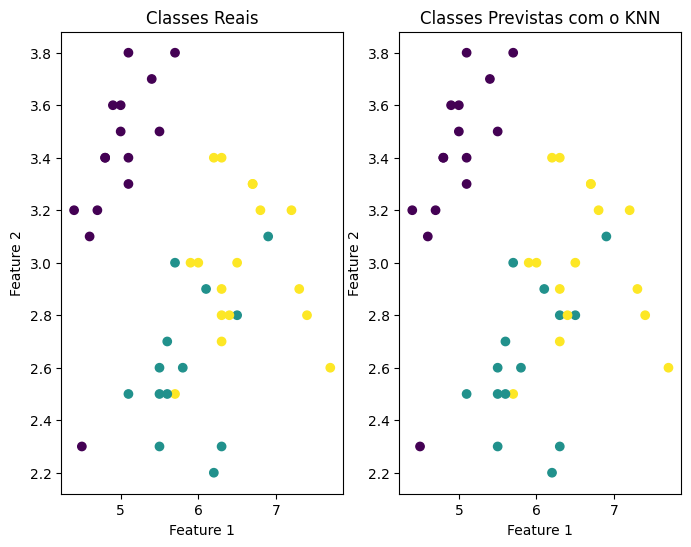

In [537]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(8,6))
#plotando as classes originais
ax1.scatter(iris_valid_x[:,0], iris_valid_x[:,1], c=iris_valid_y)
ax1.set_xlabel("Feature 1")
ax1.set_ylabel("Feature 2")
ax1.set_title("Classes Reais")

#plotando o que foi previsto
predicao =  modelo.predict(iris_valid_x)
ax2.scatter(iris_valid_x[:,0], iris_valid_x[:,1], c=predicao)
ax2.set_xlabel("Feature 1")
ax2.set_ylabel("Feature 2")
ax2.set_title("Classes Previstas com o KNN")



plt.show()

In [538]:
print("Tamanho real:", len(iris_valid_x))
print("Tamanho previsto:", len(predicao))

Tamanho real: 45
Tamanho previsto: 45


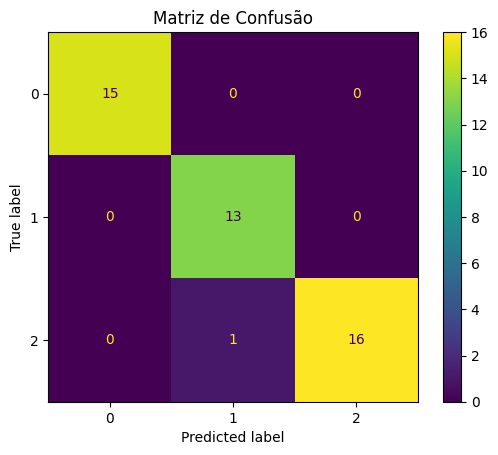

In [539]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(iris_valid_y, predicao)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Matriz de Confusão")
plt.show()